# Make Predictions on Training Data

In [1]:
# Import Packages
import ultralytics
from ultralytics import YOLO
import numpy as np
import time
import yaml
from pathlib import Path
import torch
import pandas as pd
from shutil import copy2

#-- Directories and Paths --#
REPO_ROOT = Path("..")      

DATA_CONFIG_PATH = REPO_ROOT / 'configurations' / 'model_data-seg.yaml'

#-- Model --#

# Load model parameters / overrides
with open(REPO_ROOT / 'configurations' / 'val_model_overrides.yaml', 'r') as f:
    overrides = yaml.safe_load(f)

# Override path in your dictionary
overrides['data'] = str(DATA_CONFIG_PATH)

# Assign Trained Model Weights
def resolve(p: str | Path) -> Path:
    p = Path(p)
    return p if p.is_absolute() else (REPO_ROOT / p)

weights_path = resolve(overrides.pop("weights"))

# Load Trained Model's Weights
model = YOLO(str(weights_path))  

# Predictions from the model
with torch.inference_mode():
    metrics = model.val(**overrides)


#-- Results --#

#--- Results Directory ---#
# where YOLO saved this run
out_dir = Path(metrics.save_dir)
out_dir.mkdir(parents=True, exist_ok=True)

#--- Precision & Recall Calculations ---#

# names -> {id: name}; confusion matrix includes a last row/col for "background"
names = [metrics.names[i] for i in range(len(metrics.names))]
cm = metrics.confusion_matrix.matrix.astype(np.int64)   # shape = (nc+1, nc+1) # cm = confusion_matrix
nc = len(names) # nc = name classes

# diagonal (exclude background) = TP
tp = np.diag(cm)[:nc]

# row sums (include background col) minus TP = FP for that predicted class
fp = cm[:nc, :].sum(axis=1) - tp

# column sums (include background row) minus TP = FN for that true class
fn = cm[:, :nc].sum(axis=0) - tp

precision = tp / (tp + fp + 1e-16)
recall    = tp / (tp + fn + 1e-16)
f1        = 2 * precision * recall / (precision + recall + 1e-16)

df = pd.DataFrame({
    "class": names, "TP": tp, "FP": fp, "FN": fn,
    "precision": precision, "recall": recall, "f1": f1
})
print(df)
# Output P&R Results
df.to_csv(out_dir / "P&R_results.csv", header=True,index=True)   
print(f"Saved df results metrics to {out_dir/'df_results.csv'}")


#-- Export Validation Results --#
# dataframe
validation_df = metrics.to_df()

# validation_df.to_csv(csv_path, header=True, index=True)
summary_df = pd.DataFrame([metrics.results_dict])  # <-- dict -> one-row DataFrame
summary_df.to_csv(out_dir / "summary_metrics_results.csv", index=False)
print(f"Saved metrics to {out_dir/'results.csv'}")




# choose task: 'seg' for masks, 'box' for boxes
task = 'seg' # Choosing specific 'task' type of 'segmentation' selects for metric associates
seg_metrics = getattr(metrics, task)

print(f"AP@0.75 ({task}): {seg_metrics.map75:.4f}")
print(f"AP@0.50 ({task}): {seg_metrics.map50:.4f}")
print(f"Classes  mAP@0.50:0.95 ({task}): {seg_metrics.map:.4f}")

# Per-class mAP (COCO mAP@0.50:0.95) if exposed
names = metrics.names if isinstance(metrics.names, (list, tuple)) else list(metrics.names.values())
if hasattr(seg_metrics, "maps") and seg_metrics.maps is not None:
    for i, name in enumerate(names):
        print(f"{name:>16}  mAP@0.50:0.95 = {seg_metrics.maps[i]:.4f}")


# Copy test_parameters into output folder
test_model_overrides = Path(REPO_ROOT / 'configurations/val_model_overrides.yaml')
copy2(test_model_overrides, metrics.save_dir / test_model_overrides.name )
try:
    print(f'"val_model_parameters" Copied to : {metrics.save_dir}')
except Exception:
    print('Error - Parameters Not Copied To Output')

# State output location
try:
    print("Output Metrics Saved to:", metrics.save_dir)
except Exception:
    print('Error - Location Not Printed')

Ultralytics 8.3.185  Python-3.11.14 torch-2.0.1+cu117 CUDA:0 (NVIDIA RTX A2000 12GB, 12281MiB)
YOLO11m-seg summary (fused): 138 layers, 22,336,854 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access  (ping: 0.40.1 ms, read: 196.518.9 MB/s, size: 3072.3 KB)


val: Scanning C:\Users\hmanasi1\Documents\ADML\solafune_tree_canopy\data\processed\labels\val.cache... 30 images, 0 bac
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP

requirements: Ultralytics requirement ['faster-coco-eval>=1.6.7'] not found, attempting AutoUpdate...

requirements: AutoUpdate success  6.9s
WARNING requirements: Restart runtime or rerun command for updates to take effect

WARNING Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP

WARNING Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP


                   all         30       7960      0.577      0.256      0.416      0.242      0.591      0.257      0.425      0.202
       individual_tree         30       7104      0.695      0.388      0.555      0.318      0.683      0.382      0.546      0.251
        group_of_trees         26        856      0.459      0.123      0.276      0.166      0.498      0.133      0.305      0.152
Speed: 4.5ms preprocess, 89.4ms inference, 0.0ms loss, 26.5ms postprocess per image
Saving runs\segment\val_Yolo11m_canopy_adamW_\predictions.json...
Results saved to runs\segment\val_Yolo11m_canopy_adamW_
             class    TP    FP    FN  precision    recall        f1
0  individual_tree  2836  1131  4268   0.714898  0.399212  0.512330
1   group_of_trees   105   124   751   0.458515  0.122664  0.193548
Saved df results metrics to runs\segment\val_Yolo11m_canopy_adamW_\df_results.csv
Saved metrics to runs\segment\val_Yolo11m_canopy_adamW_\results.csv
AP@0.75 (seg): 0.1661
AP@0.50 (seg): 0.42

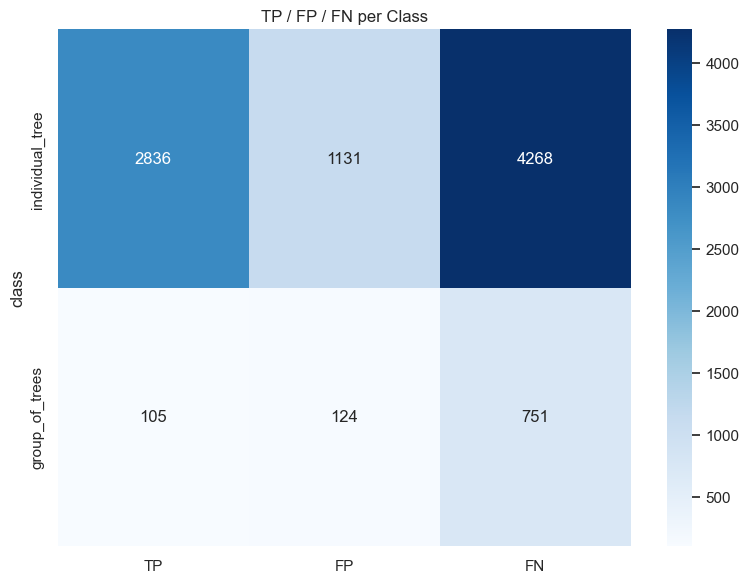

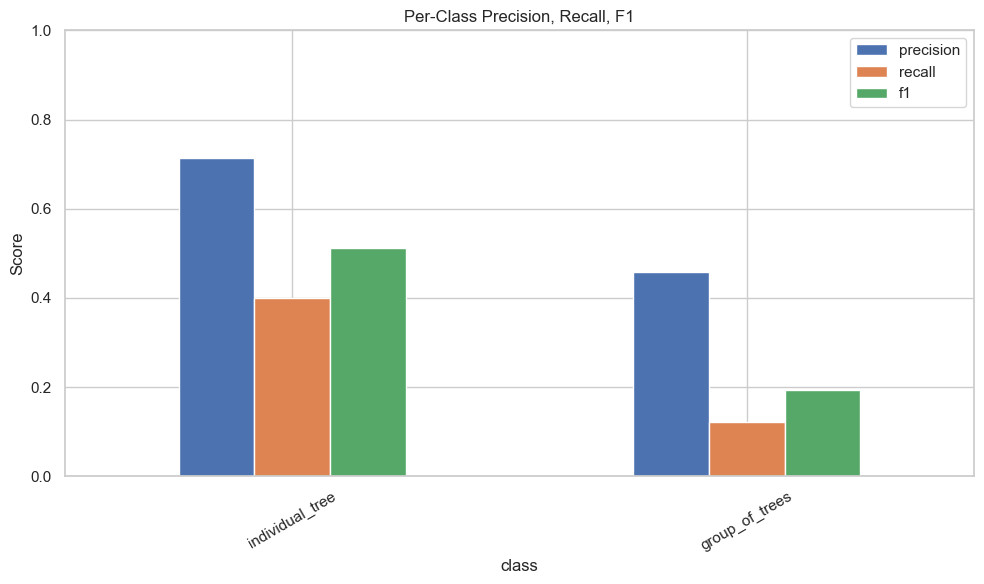

C:\Users\hmanasi1\AppData\Local\Temp\2\ipykernel_15176\4188559471.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=map_df, x="class", y="mAP50-95", palette="viridis")


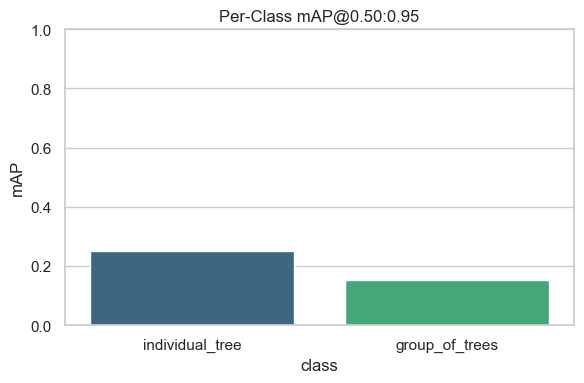

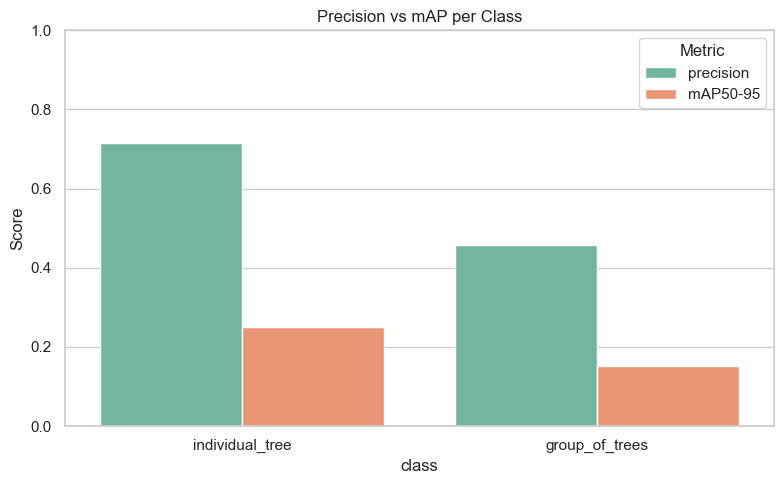

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

# ---------- Settings ----------
out_dir = Path("runs/segment/val_Yolo11m_canopy_adamW_")  # replace with metrics.save_dir if dynamic
sns.set(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

# ---------- Load per-class TP/FP/FN and Precision/Recall/F1 ----------
df = pd.read_csv(out_dir / "P&R_results.csv", index_col=0)  # from your existing code

# ---------- Load per-class mAP ----------
# Replace these values with actual seg_metrics.maps if you have them dynamically
map_df = pd.DataFrame({
    "class": df["class"],
    "mAP50-95": [0.2514, 0.1518]  # example values for individual_tree and group_of_trees
})

# ---------- 1. Confusion Matrix Heatmap (TP/FP/FN) ----------
cm_df = df.set_index("class")[["TP","FP","FN"]]

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("TP / FP / FN per Class")
plt.savefig(out_dir / "confusion_matrix.png")
plt.show()

# ---------- 2. Precision / Recall / F1 Bar Chart ----------
metrics_plot = df.set_index("class")[["precision","recall","f1"]]

metrics_plot.plot(kind='bar', figsize=(10,6))
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, F1")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(out_dir / "per_class_PRF.png")
plt.show()

# ---------- 3. Per-Class mAP Bar Chart ----------
plt.figure(figsize=(6,4))
sns.barplot(data=map_df, x="class", y="mAP50-95", palette="viridis")
plt.ylim(0,1)
plt.title("Per-Class mAP@0.50:0.95")
plt.ylabel("mAP")
plt.savefig(out_dir / "per_class_mAP.png")
plt.show()

# ---------- 4. Combined Precision vs mAP Chart ----------
combined_df = df.merge(map_df, on="class")
combined_df = combined_df.melt(id_vars="class", value_vars=["precision","mAP50-95"], 
                               var_name="Metric", value_name="Score")

plt.figure(figsize=(8,5))
sns.barplot(data=combined_df, x="class", y="Score", hue="Metric", palette="Set2")
plt.ylim(0,1)
plt.title("Precision vs mAP per Class")
plt.savefig(out_dir / "precision_vs_mAP.png")
plt.show()


# Make Prediction On Evaluation Data

In [3]:
import ultralytics
from ultralytics import YOLO
import numpy as np
import time
import yaml
from pathlib import Path
import torch
from datetime import datetime

REPO_ROOT = Path("..")   

# Load model parameters / overrides YAML
with open(REPO_ROOT / 'configurations' / 'predict_model_overrides.yaml', 'r') as f: # Modify overrides where necessary
    overrides = yaml.safe_load(f)

# Make YAML Paths Absolute
for key in ("source", "project"):
    if key in overrides:
        overrides[key] = str((REPO_ROOT / overrides[key]).resolve())

# Load Trained Model Weights
def resolve(p: str | Path) -> Path:
    p = Path(p)
    return p if p.is_absolute() else (REPO_ROOT / p)

weights_path = resolve(overrides.pop("weights"))

# Model Naming
# optional: use the training run name from the weights path
train_run = weights_path.parents[1].name  # e.g., train_Yolov8s_canopy_832_...
run_name = f"predict_{train_run}"

# inject name (and project if you want a different subfolder)
overrides.setdefault("project", str(REPO_ROOT / "runs"))
overrides["name"] = run_name
# overrides["exist_ok"] = True  # set True to overwrite instead of auto-appending _2

# Load Trained Model's Weights
model = YOLO(str(weights_path))  

# Predictions from the model
with torch.inference_mode():
    predictions = model.predict(**overrides)

# State output location

# Stream = True
for last in predictions:
    pass
print("Saved to:", last.save_dir)

# Stream = False
# print("Outputs saved to:", predictions[0].save_dir)


image 1/150 C:\Users\hmanasi1\Documents\ADML\solafune_tree_canopy\data\processed\images\predict\10cm_evaluation_1.tif: 1024x1024 45 individual_trees, 17 group_of_treess, 44.4ms
image 2/150 C:\Users\hmanasi1\Documents\ADML\solafune_tree_canopy\data\processed\images\predict\10cm_evaluation_10.tif: 1024x1024 45 individual_trees, 20 group_of_treess, 73.0ms
image 3/150 C:\Users\hmanasi1\Documents\ADML\solafune_tree_canopy\data\processed\images\predict\10cm_evaluation_11.tif: 1024x1024 35 individual_trees, 18 group_of_treess, 106.2ms
image 4/150 C:\Users\hmanasi1\Documents\ADML\solafune_tree_canopy\data\processed\images\predict\10cm_evaluation_12.tif: 1024x1024 46 individual_trees, 29 group_of_treess, 85.4ms
image 5/150 C:\Users\hmanasi1\Documents\ADML\solafune_tree_canopy\data\processed\images\predict\10cm_evaluation_13.tif: 1024x1024 129 individual_trees, 63 group_of_treess, 279.9ms
image 6/150 C:\Users\hmanasi1\Documents\ADML\solafune_tree_canopy\data\processed\images\predict\10cm_evalua

In [4]:
# Packages
from pathlib import Path
import pandas as pd
import numpy as np
import json
from PIL import Image
import pandas as pd
from datetime import datetime

# Create paths
REPO_ROOT = Path.cwd()

# Prediction Annotations
labels = "../runs/segment/predict_train_Yolo11m_canopy_adamW_\labels" # Modify Prediction Txt annotations where necessary
IMGS = '../data/processed/images/predict'
OUT_JSON = REPO_ROOT / 'exports/med_fold/submission.json'



#---Define Functions---#

# Image Metadata
def get_meta(IMGS):

    meta_data = {}
    scene_type_default = "Unknown"
    IMGS = Path(IMGS)

    if IMGS.exists():

        for p in Path(IMGS).iterdir():
            if p.suffix.lower() not in {".tif"}: # All images .tif
                continue
            file_name = p.name
            cm_resolution = str(file_name[0:2])

            with Image.open(p) as image: # Pillow / Pill package
                width, height = image.size

            meta_data[file_name] = {
                'file_name' : file_name,
                "width" : width,
                'height' : height,
                "cm_resolution" : cm_resolution,
                "scene_type" : scene_type_default

            }
    else:
      print('Error - IMGs Not Exist')
    return meta_data

# Get Annotations
def get_annotations(LABELS):
    annotations = []

    for txt_file in sorted(Path(LABELS).iterdir()):
        
        if txt_file.is_file() and txt_file.suffix.lower() == ".txt":
            image_name = txt_file.name

            with open(txt_file, 'r') as file:
                for line in file:

                    # 1. Split the line into tokens
                    tokens = line.strip().split()

                    # 2. Convert tokens into usable pieces
                    class_id = int(tokens[0])                    # first token
                    *coords, confidence_level = map(float, tokens[1:])  
                    # all middle tokens are coords, last one is confidence
                    

                    # 3. Group coords into pairs (x,y)
                    segmentation = [
                        (coords[i], coords[i+1])
                        for i in range(0, len(coords), 2)
                    ]

                    # 4. Save everything into dict
                    annotations.append({
                        "image": image_name,
                        "class": class_id,
                        "confidence_level": confidence_level,
                        "segmentation": segmentation
                    })

    return annotations


# Denormalise segmentations to pixels

def denorm_segmentation(seg, width, height, *, flatten=True, round_int=True):
    """
    seg: list of (x,y) pairs in [0,1]
    returns: flat pixel list [x1,y1,x2,y2,...] (default) or list of pairs
    """
    # If seg is already flat [x1,y1,...], turn into pairs
    if seg and not isinstance(seg[0], (list, tuple)):
        it = iter(seg)
        seg_pairs = list(zip(it, it))
    else:
        seg_pairs = seg

    out = []
    for x, y in seg_pairs:
        X = max(0.0, min(width  - 1, x * width))
        Y = max(0.0, min(height - 1, y * height))
        if round_int:
            X = int(round(X))
            Y = int(round(Y))
        if flatten:
            out.extend([X, Y])
        else:
            out.append((X, Y))
    return out


# Append annotations to images

def append_imgs_annotations(img_list, annot_list):
    # ensure each image has an annotations list
    for img in img_list:
        if "annotations" not in img or img["annotations"] is None:
            img["annotations"] = []

    for image in img_list:
        w, h = image["width"], image["height"]
        fname = image["file_name"]

        # all annots for this image
        matched = (a for a in annot_list if a["image"] == fname)

        for a in matched:
            seg_px = denorm_segmentation(a["segmentation"], w, h, flatten=True, round_int=True) # Denormalise Segemetation to Pixels

            image["annotations"].append({
                "class": a["class"],
                "confidence_score": float(a["confidence_level"]),  # or keep as formatted string if you prefer
                "segmentation": seg_px
            })

    return img_list


# class id
ID_to_Name = {
    0 : 'individual_tree',
    1 : 'group_of_trees'
}



#--Procedure--#
print('Get Meta Data')
meta = get_meta(IMGS) # Retrieve Meta Data
meta_2items = list(meta.items())[:1]
meta_2keys = list(meta)[:1]

print(f'Meta Data Items : {meta_2items}')

print(f'Meta Data Keys : {meta_2items}')


images = [] # Produce Images list

print('Append Meta Data To Images List')
for m in meta.values(): # Append Meta Data to Images List
    images.append({
        'file_name' : m['file_name'],
        'width' : m['width'],
        'height' : m['height'],
        'cm_resolution' : m['cm_resolution'],
        'scene_type' : m['scene_type'],
        'annotations' : []
    })
    

images_sorted = sorted(images, key=lambda x: x['file_name']) # Sort Images
print(f'images_sorted ')
    
print('Get Annotations')
annotations_list = get_annotations(labels) # Retrieve Annotations & Denormalise Segmentations to Pixels

for annot in annotations_list: # Clean Annotations
    # .txt suffix -> .tif
    annot['image'] = annot['image'][:-4] + '.tif'

    # map class id -> name
    annot['class'] = ID_to_Name.get(annot['class'], 'Unknown')

    # convert confidence_level -> percentage string
    annot['confidence_level'] = f"{annot['confidence_level']:.2f}"

if annotations_list and len(annotations_list[0]) > 0:
    print('Annotations List Completed')

appended_list = append_imgs_annotations(images_sorted, annotations_list) # Append Annotations to Images

print(f'Appended_list Outputed ')

predict_answer = {}
predict_answer = {'images' : appended_list}
print(f'Predict_Answer Formulated')


# Assign Scene Type from Sample Answer to Submission

sample_answer_input = REPO_ROOT / 'exports/sample_answer.json' # Acquire Sample Answer path 

with open(sample_answer_input) as f: # Open Sample Answer Structure
    sample_answer = json.load(f)

sample_answer = sample_answer['images']


image_scenes = [] # Create list of images and associated 'scene_type'

for image in sample_answer:
    file_name = image.get('file_name') # GET each image's name
    scene_type = image.get('scene_type') # GET each image's scene_type

    image_scenes.append(  # Append to list
        {
            'filename':file_name, 
            'scene_type':scene_type
        }
    )


pd.json_normalize(image_scenes) #-- Potential redunant code --#

image_scenes_df = pd.DataFrame(image_scenes) # Transform Image_scenes list into DF

scene_map = image_scenes_df.set_index('filename')['scene_type'].to_dict() # Restructure image_scenes DF

submission = predict_answer

print('Append scene_types to predict_answer')
# Update each image in submission['images']
for image in submission['images']:
    filename = image['file_name']
    if image['scene_type'] == "Unknown" and filename in scene_map:
        image['scene_type'] = scene_map[filename]



print('Export Submission')
# Rewrite Submission JSON File
OUT_JSON.parent.mkdir(parents=True, exist_ok=True)
with open(OUT_JSON, "w") as f:
    json.dump(submission, f, indent=2)


print(f"Export Submission Complete \
      Saved As: 'Submission' \
      Saved At : {OUT_JSON}")


Get Meta Data
Meta Data Items : [('10cm_evaluation_1.tif', {'file_name': '10cm_evaluation_1.tif', 'width': 1024, 'height': 1024, 'cm_resolution': '10', 'scene_type': 'Unknown'})]
Meta Data Keys : [('10cm_evaluation_1.tif', {'file_name': '10cm_evaluation_1.tif', 'width': 1024, 'height': 1024, 'cm_resolution': '10', 'scene_type': 'Unknown'})]
Append Meta Data To Images List
images_sorted 
Get Annotations
Annotations List Completed
Appended_list Outputed 
Predict_Answer Formulated
Append scene_types to predict_answer
Export Submission
Export Submission Complete       Saved As: 'Submission'       Saved At : C:\Users\hmanasi1\Documents\ADML\solafune_tree_canopy\notebooks\exports\med_fold\submission.json
